# Ressourcenschonende Hyperparameteroptimierung mit MobileNetV2

Dieses Notebook basiert auf deinem bisherigen MobileNetV2-Notebook für die Klassifikation von Äpfeln in **Healthy** und **Rotten**.

Die Idee ist bewusst ressourcenschonend:

1. **MobileNetV2 bleibt zunächst eingefroren**  
   → Es wird nur der kleine Klassifikationskopf trainiert.

2. **Mehrere kleine Varianten werden kurz getestet**  
   → Dense-Neuronen, Dropout und Learning Rate werden verglichen.

3. **Nur die besten Modelle werden fine-getuned**  
   → Fine-Tuning ist teuer und wird deshalb nur für die Top-Modelle gemacht.

4. **Die finale Bewertung erfolgt auf dem Testset**  
   → Testdaten werden nicht zur Optimierung verwendet.

## 1. Imports & Grundkonfiguration

In [2]:
import os
import json
import itertools
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger

from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow Version:", tf.__version__)
print("GPU verfügbar:", tf.config.list_physical_devices("GPU"))

# Reproduzierbarkeit
SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

TensorFlow Version: 2.21.0
GPU verfügbar: []


In [3]:
# ── Konfiguration ──────────────────────────────────────────────────────────────
# Passe diesen Pfad bei Bedarf an.
DATA_DIR = Path(r"c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Apple_Data_sing")

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42

# Ressourcenschonende Suche
SEARCH_EPOCHS = 5          # kurze Trainingsdauer je Kandidat
SEARCH_PATIENCE = 2        # früher Abbruch, wenn keine Verbesserung
MAX_TRIALS = None          # z.B. 8 setzen, wenn du nur 8 Varianten testen möchtest; None = alle
TOP_K = 3                  # nur die besten K Modelle werden später weiter betrachtet

# Fine-Tuning nur für die besten Modelle
FINETUNE_EPOCHS = 3
FINETUNE_PATIENCE = 2

# Ausgabeordner
OUTPUT_DIR = Path("hyperparameter_results")
OUTPUT_DIR.mkdir(exist_ok=True)

RESULTS_CSV = OUTPUT_DIR / "hyperparameter_results.csv"
BEST_CONFIG_JSON = OUTPUT_DIR / "best_config.json"
BEST_MODEL_PATH = OUTPUT_DIR / "best_mobilenet_hyperparameter.keras"

print("Datenpfad:", DATA_DIR)
print("Output-Ordner:", OUTPUT_DIR.resolve())

Datenpfad: c:\Users\benke\Downloads\archive\Fruit And Vegetable Diseases Dataset\Apple_Data_sing
Output-Ordner: C:\Users\benke\OneDrive\Desktop\Projekt Wirtschaftsinformatik\notebooks\hyperparameter_results


## 2. Dataset laden und in Training / Validation / Test aufteilen

In [4]:
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"DATA_DIR existiert nicht: {DATA_DIR}\n"
        "Passe den Pfad in der Konfigurationszelle an."
    )

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds_raw.class_names
num_classes = len(class_names)

# Validation-Teil wird halbiert: 15% Validation, 15% Test
# Wichtig: Testdaten werden erst ganz am Ende zur Bewertung verwendet.
temp_batches = temp_ds_raw.cardinality().numpy()
val_batches = temp_batches // 2

val_ds_raw = temp_ds_raw.take(val_batches)
test_ds_raw = temp_ds_raw.skip(val_batches)

print("Klassen:", class_names)
print("Anzahl Klassen:", num_classes)
print("Training Batches:", train_ds_raw.cardinality().numpy())
print("Validation Batches:", val_ds_raw.cardinality().numpy())
print("Test Batches:", test_ds_raw.cardinality().numpy())

Found 4817 files belonging to 2 classes.
Using 3372 files for training.
Found 4817 files belonging to 2 classes.
Using 1445 files for validation.
Klassen: ['Apple__Healthy', 'Apple__Rotten']
Anzahl Klassen: 2
Training Batches: 106
Validation Batches: 23
Test Batches: 23


## 3. Data Augmentation und Performance-Optimierung

In [5]:
# Data Augmentation wird nur auf Trainingsdaten angewendet.
# Validation und Test bleiben unverändert.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.1),
], name="augmentation")

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds_raw.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

val_ds = val_ds_raw.prefetch(AUTOTUNE)
test_ds = test_ds_raw.prefetch(AUTOTUNE)

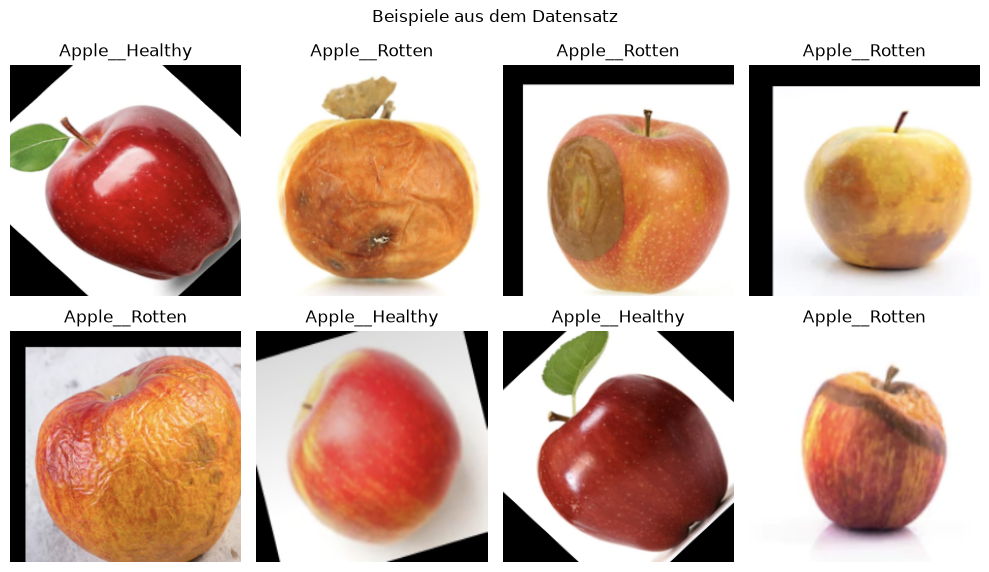

In [6]:
# Beispielbilder anzeigen
plt.figure(figsize=(10, 6))
for images, labels in train_ds_raw.take(1):
    for i in range(min(8, len(images))):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.suptitle("Beispiele aus dem Datensatz")
plt.tight_layout()
plt.show()

## 4. Modell-Funktion: MobileNetV2 + variabler Klassifikationskopf

In [7]:
def build_model(
    num_classes: int,
    dense_units: int = 256,
    dropout_rate: float = 0.4,
    learning_rate: float = 1e-3,
    finetune: bool = False,
    finetune_from: int = 100,
):
    """
    Baut ein MobileNetV2-Modell.

    finetune=False:
        MobileNetV2 ist eingefroren. Nur der Klassifikationskopf wird trainiert.

    finetune=True:
        MobileNetV2 wird ab Layer finetune_from teilweise aufgetaut.
    """
    base_model = MobileNetV2(
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
        include_top=False,
        weights="imagenet"
    )

    if finetune:
        base_model.trainable = True
        for layer in base_model.layers[:finetune_from]:
            layer.trainable = False
    else:
        base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        layers.Rescaling(scale=1./127.5, offset=-1.0, name="mobilenet_preprocess"),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(dense_units, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation="softmax")
    ], name="MobileNetV2_Hyperparameteroptimierung")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 5. Suchraum definieren

In [8]:
# Kleiner Suchraum: ressourcenschonend und für dein Projekt gut begründbar.
# Du kannst später einzelne Werte ergänzen, aber starte bewusst klein.
search_space = {
    "dense_units": [128, 256],
    "dropout_rate": [0.3, 0.4, 0.5],
    "learning_rate": [1e-3, 5e-4],
}

all_configs = list(itertools.product(
    search_space["dense_units"],
    search_space["dropout_rate"],
    search_space["learning_rate"]
))

if MAX_TRIALS is not None:
    all_configs = all_configs[:MAX_TRIALS]

print(f"Anzahl zu testender Varianten: {len(all_configs)}")
for i, cfg in enumerate(all_configs, start=1):
    print(i, cfg)

Anzahl zu testender Varianten: 12
1 (128, 0.3, 0.001)
2 (128, 0.3, 0.0005)
3 (128, 0.4, 0.001)
4 (128, 0.4, 0.0005)
5 (128, 0.5, 0.001)
6 (128, 0.5, 0.0005)
7 (256, 0.3, 0.001)
8 (256, 0.3, 0.0005)
9 (256, 0.4, 0.001)
10 (256, 0.4, 0.0005)
11 (256, 0.5, 0.001)
12 (256, 0.5, 0.0005)


## 6. Phase 1: Hyperparameter-Suche mit eingefrorenem MobileNetV2

In [9]:
def train_candidate(dense_units, dropout_rate, learning_rate, trial_id):
    """Trainiert eine Kandidaten-Konfiguration kurz und gibt die Ergebnisse zurück."""
    tf.keras.backend.clear_session()

    model = build_model(
        num_classes=num_classes,
        dense_units=dense_units,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        finetune=False
    )

    candidate_path = OUTPUT_DIR / f"candidate_{trial_id:02d}.keras"
    log_path = OUTPUT_DIR / f"candidate_{trial_id:02d}_log.csv"

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=SEARCH_PATIENCE, restore_best_weights=True, verbose=1),
        ModelCheckpoint(filepath=candidate_path, monitor="val_loss", save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, verbose=1),
        CSVLogger(log_path)
    ]

    print("\n" + "="*70)
    print(f"Trial {trial_id}")
    print(f"dense_units={dense_units}, dropout_rate={dropout_rate}, learning_rate={learning_rate}")
    print("="*70)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=SEARCH_EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    best_val_accuracy = float(max(history.history["val_accuracy"]))
    best_val_loss = float(min(history.history["val_loss"]))
    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    return {
        "trial_id": trial_id,
        "dense_units": dense_units,
        "dropout_rate": dropout_rate,
        "learning_rate": learning_rate,
        "best_val_accuracy": best_val_accuracy,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "model_path": str(candidate_path),
        "log_path": str(log_path),
    }

In [10]:
results = []

for trial_id, (dense_units, dropout_rate, learning_rate) in enumerate(all_configs, start=1):
    result = train_candidate(
        dense_units=dense_units,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        trial_id=trial_id
    )
    results.append(result)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by=["best_val_accuracy", "best_val_loss"],
    ascending=[False, True]
).reset_index(drop=True)

results_df.to_csv(RESULTS_CSV, index=False)
results_df



Trial 1
dense_units=128, dropout_rate=0.3, learning_rate=0.001
Epoch 1/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 80s 672ms/step - accuracy: 0.9356 - loss: 0.1784 - val_accuracy: 0.9783 - val_loss: 0.0671 - learning_rate: 0.0010
Epoch 2/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 82s 669ms/step - accuracy: 0.9721 - loss: 0.0771 - val_accuracy: 0.9891 - val_loss: 0.0369 - learning_rate: 0.0010
Epoch 3/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.9777 - loss: 0.0626
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
106/106 ━━━━━━━━━━━━━━━━━━━━ 78s 634ms/step - accuracy: 0.9786 - loss: 0.0563 - val_accuracy: 0.9837 - val_loss: 0.0679 - learning_rate: 0.0010
Epoch 4/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 71s 667ms/step - accuracy: 0.9870 - loss: 0.0367 - val_accuracy: 0.9851 - val_loss: 0.0356 - learning_rate: 5.0000e-04
Epoch 5/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.9875 - loss: 0.0294
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

,trial_id,dense_units,dropout_rate,learning_rate,best_val_accuracy,best_val_loss,best_epoch,model_path,log_path
0,3,128,0.4,0.0010,0.995924,0.032455,4,hyperparameter_results\candidate_03.keras,hyperparameter_results\candidate_03_log.csv
1,7,256,0.3,0.0010,0.995924,0.035835,5,hyperparameter_results\candidate_07.keras,hyperparameter_results\candidate_07_log.csv
2,10,256,0.4,0.0005,0.993207,0.032573,4,hyperparameter_results\candidate_10.keras,hyperparameter_results\candidate_10_log.csv
3,2,128,0.3,0.0005,0.993207,0.033452,5,hyperparameter_results\candidate_02.keras,hyperparameter_results\candidate_02_log.csv
4,9,256,0.4,0.0010,0.990489,0.035229,4,hyperparameter_results\candidate_09.keras,hyperparameter_results\candidate_09_log.csv
5,8,256,0.3,0.0005,0.990489,0.040803,5,hyperparameter_results\candidate_08.keras,hyperparameter_results\candidate_08_log.csv
6,11,256,0.5,0.0010,0.990489,0.042728,5,hyperparameter_results\candidate_11.keras,hyperparameter_results\candidate_11_log.csv
7,1,128,0.3,0.0010,0.989130,0.035556,4,hyperparameter_results\candidate_01.keras,hyperparameter_results\candidate_01_log.csv
8,4,128,0.4,0.0005,0.989130,0.044627,5,hyperparameter_results\candidate_04.keras,hyperparameter_results\candidate_04_log.csv
9,12,256,0.5,0.0005,0.987772,0.047541,4,hyperparameter_results\candidate_12.keras,hyperparameter_results\candidate_12_log.csv


## 7. Ergebnisse der Hyperparameter-Suche visualisieren

In [11]:
# Tabelle erneut laden, falls du das Notebook später ab hier weiterlaufen lässt.
if not RESULTS_CSV.exists():
    raise FileNotFoundError("Die Ergebnisdatei wurde noch nicht erstellt. Führe zuerst die Suche aus.")

results_df = pd.read_csv(RESULTS_CSV)
results_df = results_df.sort_values(
    by=["best_val_accuracy", "best_val_loss"],
    ascending=[False, True]
).reset_index(drop=True)

results_df

,trial_id,dense_units,dropout_rate,learning_rate,best_val_accuracy,best_val_loss,best_epoch,model_path,log_path
0,3,128,0.4,0.0010,0.995924,0.032455,4,hyperparameter_results\candidate_03.keras,hyperparameter_results\candidate_03_log.csv
1,7,256,0.3,0.0010,0.995924,0.035835,5,hyperparameter_results\candidate_07.keras,hyperparameter_results\candidate_07_log.csv
2,10,256,0.4,0.0005,0.993207,0.032573,4,hyperparameter_results\candidate_10.keras,hyperparameter_results\candidate_10_log.csv
3,2,128,0.3,0.0005,0.993207,0.033452,5,hyperparameter_results\candidate_02.keras,hyperparameter_results\candidate_02_log.csv
4,9,256,0.4,0.0010,0.990489,0.035229,4,hyperparameter_results\candidate_09.keras,hyperparameter_results\candidate_09_log.csv
5,8,256,0.3,0.0005,0.990489,0.040803,5,hyperparameter_results\candidate_08.keras,hyperparameter_results\candidate_08_log.csv
6,11,256,0.5,0.0010,0.990489,0.042728,5,hyperparameter_results\candidate_11.keras,hyperparameter_results\candidate_11_log.csv
7,1,128,0.3,0.0010,0.989130,0.035556,4,hyperparameter_results\candidate_01.keras,hyperparameter_results\candidate_01_log.csv
8,4,128,0.4,0.0005,0.989130,0.044627,5,hyperparameter_results\candidate_04.keras,hyperparameter_results\candidate_04_log.csv
9,12,256,0.5,0.0005,0.987772,0.047541,4,hyperparameter_results\candidate_12.keras,hyperparameter_results\candidate_12_log.csv


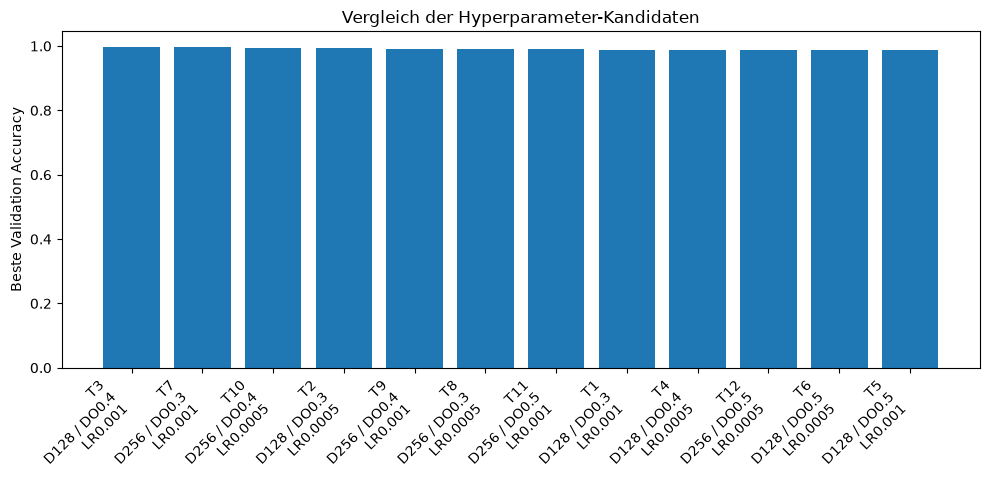

In [12]:
plt.figure(figsize=(10, 5))
labels = [
    f"T{int(row.trial_id)}\nD{int(row.dense_units)} / DO{row.dropout_rate}\nLR{row.learning_rate:g}"
    for _, row in results_df.iterrows()
]

plt.bar(range(len(results_df)), results_df["best_val_accuracy"])
plt.xticks(range(len(results_df)), labels, rotation=45, ha="right")
plt.ylabel("Beste Validation Accuracy")
plt.title("Vergleich der Hyperparameter-Kandidaten")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "hyperparameter_vergleich.png", dpi=150)
plt.show()

In [13]:
best_config = results_df.iloc[0].to_dict()

with open(BEST_CONFIG_JSON, "w", encoding="utf-8") as f:
    json.dump(best_config, f, indent=4)

print("Beste Konfiguration:")
print(json.dumps(best_config, indent=4))
print("Gespeichert in:", BEST_CONFIG_JSON)

Beste Konfiguration:
{
    "trial_id": 3,
    "dense_units": 128,
    "dropout_rate": 0.4,
    "learning_rate": 0.001,
    "best_val_accuracy": 0.9959239363670348,
    "best_val_loss": 0.0324553623795509,
    "best_epoch": 4,
    "model_path": "hyperparameter_results\\candidate_03.keras",
    "log_path": "hyperparameter_results\\candidate_03_log.csv"
}
Gespeichert in: hyperparameter_results\best_config.json


In [14]:
# Bestes Modell aus der ersten Hyperparameter-Suche laden
# also: OHNE Fine-Tuning

best_head_model_path = best_config["model_path"]

best_head_model = tf.keras.models.load_model(best_head_model_path)

print("Bestes Modell ohne Fine-Tuning:")
print("Trial:", best_config["trial_id"])
print("Dense Units:", best_config["dense_units"])
print("Dropout:", best_config["dropout_rate"])
print("Learning Rate:", best_config["learning_rate"])
print("Model Path:", best_head_model_path)

print("\n=== Test-Set Evaluation ohne Fine-Tuning ===")
test_loss, test_acc = best_head_model.evaluate(test_ds, verbose=1)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

Bestes Modell ohne Fine-Tuning:
Trial: 3
Dense Units: 128
Dropout: 0.4
Learning Rate: 0.001
Model Path: hyperparameter_results\candidate_03.keras

=== Test-Set Evaluation ohne Fine-Tuning ===
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 451ms/step - accuracy: 0.9901 - loss: 0.0284
Test Accuracy: 0.9901
Test Loss:     0.0284


## 8. Phase 2: Fine-Tuning nur für die besten Kandidaten

In [14]:
# Fine-Tuning-Suchraum bewusst klein halten.
# Dadurch bleibt der Aufwand überschaubar.
finetune_from_options = [100, 120, 140]
finetune_lr_options = [1e-5, 5e-6]

top_candidates = results_df.head(TOP_K).copy()
print(f"Es werden nur die besten {len(top_candidates)} Kandidaten fine-getuned.")
top_candidates

Es werden nur die besten 3 Kandidaten fine-getuned.


,trial_id,dense_units,dropout_rate,learning_rate,best_val_accuracy,best_val_loss,best_epoch,model_path,log_path
0,3,128,0.4,0.0010,0.995924,0.032455,4,hyperparameter_results\candidate_03.keras,hyperparameter_results\candidate_03_log.csv
1,7,256,0.3,0.0010,0.995924,0.035835,5,hyperparameter_results\candidate_07.keras,hyperparameter_results\candidate_07_log.csv
2,10,256,0.4,0.0005,0.993207,0.032573,4,hyperparameter_results\candidate_10.keras,hyperparameter_results\candidate_10_log.csv


In [15]:
def train_finetune_candidate(base_row, finetune_from, finetune_lr, finetune_trial_id):
    """Baut das Modell mit gleicher Head-Konfiguration neu und trainiert es mit Fine-Tuning."""
    tf.keras.backend.clear_session()

    model = build_model(
        num_classes=num_classes,
        dense_units=int(base_row["dense_units"]),
        dropout_rate=float(base_row["dropout_rate"]),
        learning_rate=finetune_lr,
        finetune=True,
        finetune_from=finetune_from
    )

    finetune_path = OUTPUT_DIR / f"finetune_{finetune_trial_id:02d}.keras"
    log_path = OUTPUT_DIR / f"finetune_{finetune_trial_id:02d}_log.csv"

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=FINETUNE_PATIENCE, restore_best_weights=True, verbose=1),
        ModelCheckpoint(filepath=finetune_path, monitor="val_loss", save_best_only=True, verbose=0),
        CSVLogger(log_path)
    ]

    print("\n" + "="*70)
    print(f"Fine-Tuning Trial {finetune_trial_id}")
    print(f"Ausgangs-Trial: {int(base_row['trial_id'])}")
    print(f"dense_units={int(base_row['dense_units'])}, dropout={float(base_row['dropout_rate'])}")
    print(f"finetune_from={finetune_from}, finetune_lr={finetune_lr}")
    print("="*70)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FINETUNE_EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    best_val_accuracy = float(max(history.history["val_accuracy"]))
    best_val_loss = float(min(history.history["val_loss"]))
    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    return {
        "finetune_trial_id": finetune_trial_id,
        "base_trial_id": int(base_row["trial_id"]),
        "dense_units": int(base_row["dense_units"]),
        "dropout_rate": float(base_row["dropout_rate"]),
        "head_learning_rate": float(base_row["learning_rate"]),
        "finetune_from": finetune_from,
        "finetune_learning_rate": finetune_lr,
        "best_val_accuracy": best_val_accuracy,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "model_path": str(finetune_path),
        "log_path": str(log_path),
    }

In [16]:
finetune_results = []
finetune_trial_id = 1

for _, base_row in top_candidates.iterrows():
    for finetune_from in finetune_from_options:
        for finetune_lr in finetune_lr_options:
            result = train_finetune_candidate(
                base_row=base_row,
                finetune_from=finetune_from,
                finetune_lr=finetune_lr,
                finetune_trial_id=finetune_trial_id
            )
            finetune_results.append(result)
            finetune_trial_id += 1

finetune_results_df = pd.DataFrame(finetune_results)
finetune_results_df = finetune_results_df.sort_values(
    by=["best_val_accuracy", "best_val_loss"],
    ascending=[False, True]
).reset_index(drop=True)

finetune_results_csv = OUTPUT_DIR / "finetune_results.csv"
finetune_results_df.to_csv(finetune_results_csv, index=False)
finetune_results_df


Fine-Tuning Trial 1
Ausgangs-Trial: 3
dense_units=128, dropout=0.4
finetune_from=100, finetune_lr=1e-05
Epoch 1/3
106/106 ━━━━━━━━━━━━━━━━━━━━ 115s 936ms/step - accuracy: 0.6735 - loss: 0.7379 - val_accuracy: 0.5408 - val_loss: 0.8015
Epoch 2/3
106/106 ━━━━━━━━━━━━━━━━━━━━ 140s 918ms/step - accuracy: 0.8479 - loss: 0.3577 - val_accuracy: 0.6250 - val_loss: 0.7662
Epoch 3/3
106/106 ━━━━━━━━━━━━━━━━━━━━ 97s 912ms/step - accuracy: 0.9116 - loss: 0.2252 - val_accuracy: 0.6780 - val_loss: 0.7651
Restoring model weights from the end of the best epoch: 3.

Fine-Tuning Trial 2
Ausgangs-Trial: 3
dense_units=128, dropout=0.4
finetune_from=100, finetune_lr=5e-06
Epoch 1/3
106/106 ━━━━━━━━━━━━━━━━━━━━ 114s 934ms/step - accuracy: 0.5116 - loss: 1.2559 - val_accuracy: 0.5530 - val_loss: 0.7659
Epoch 2/3
106/106 ━━━━━━━━━━━━━━━━━━━━ 98s 915ms/step - accuracy: 0.7177 - loss: 0.7004 - val_accuracy: 0.6562 - val_loss: 0.6952
Epoch 3/3
106/106 ━━━━━━━━━━━━━━━━━━━━ 98s 921ms/step - accuracy: 0.7980 - los

,finetune_trial_id,base_trial_id,dense_units,dropout_rate,head_learning_rate,finetune_from,finetune_learning_rate,best_val_accuracy,best_val_loss,best_epoch,model_path,log_path
0,11,7,256,0.3,0.0010,140,0.000010,0.903533,0.261168,3,hyperparameter_results\finetune_11.keras,hyperparameter_results\finetune_11_log.csv
1,12,7,256,0.3,0.0010,140,0.000005,0.896739,0.244346,3,hyperparameter_results\finetune_12.keras,hyperparameter_results\finetune_12_log.csv
2,6,3,128,0.4,0.0010,140,0.000005,0.894022,0.257442,3,hyperparameter_results\finetune_06.keras,hyperparameter_results\finetune_06_log.csv
3,10,7,256,0.3,0.0010,120,0.000005,0.875000,0.306573,3,hyperparameter_results\finetune_10.keras,hyperparameter_results\finetune_10_log.csv
4,5,3,128,0.4,0.0010,140,0.000010,0.839674,0.352421,2,hyperparameter_results\finetune_05.keras,hyperparameter_results\finetune_05_log.csv
5,14,10,256,0.4,0.0005,100,0.000005,0.834239,0.366437,3,hyperparameter_results\finetune_14.keras,hyperparameter_results\finetune_14_log.csv
6,4,3,128,0.4,0.0010,120,0.000005,0.827446,0.375952,3,hyperparameter_results\finetune_04.keras,hyperparameter_results\finetune_04_log.csv
7,8,7,256,0.3,0.0010,100,0.000005,0.819293,0.407720,3,hyperparameter_results\finetune_08.keras,hyperparameter_results\finetune_08_log.csv
8,3,3,128,0.4,0.0010,120,0.000010,0.817935,0.413049,3,hyperparameter_results\finetune_03.keras,hyperparameter_results\finetune_03_log.csv
9,15,10,256,0.4,0.0005,120,0.000010,0.811141,0.384456,1,hyperparameter_results\finetune_15.keras,hyperparameter_results\finetune_15_log.csv


## 9. Bestes Fine-Tuning-Modell auswählen und kopieren

In [ ]:
finetune_results_csv = OUTPUT_DIR / "finetune_results.csv"
finetune_results_df = pd.read_csv(finetune_results_csv)
finetune_results_df = finetune_results_df.sort_values(
    by=["best_val_accuracy", "best_val_loss"],
    ascending=[False, True]
).reset_index(drop=True)

best_finetune = finetune_results_df.iloc[0].to_dict()
print("Bestes Fine-Tuning-Modell:")
print(json.dumps(best_finetune, indent=4))

# Bestes Modell laden und einheitlich speichern
best_model = tf.keras.models.load_model(best_finetune["model_path"])
best_model.save(BEST_MODEL_PATH)
print("Bestes Modell gespeichert unter:", BEST_MODEL_PATH)

Bestes Fine-Tuning-Modell:
{
    "finetune_trial_id": 11,
    "base_trial_id": 7,
    "dense_units": 256,
    "dropout_rate": 0.3,
    "head_learning_rate": 0.001,
    "finetune_from": 140,
    "finetune_learning_rate": 1e-05,
    "best_val_accuracy": 0.90353262424469,
    "best_val_loss": 0.2611675262451172,
    "best_epoch": 3,
    "model_path": "hyperparameter_results\\finetune_11.keras",
    "log_path": "hyperparameter_results\\finetune_11_log.csv"
}
Bestes Modell gespeichert unter: hyperparameter_results\best_mobilenet_hyperparameter.keras


## 10. Finale Evaluation auf dem Testset

In [29]:
model = tf.keras.models.load_model(BEST_MODEL_PATH)

print("=== Finale Test-Set Evaluation ===")
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

=== Finale Test-Set Evaluation ===
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 502ms/step - accuracy: 0.8999 - loss: 0.2748
Test Accuracy: 0.8999
Test Loss:     0.2748


=== Classification Report ===
                precision    recall  f1-score   support

Apple__Healthy       0.99      0.99      0.99       286
 Apple__Rotten       0.99      0.99      0.99       423

      accuracy                           0.99       709
     macro avg       0.99      0.99      0.99       709
  weighted avg       0.99      0.99      0.99       709



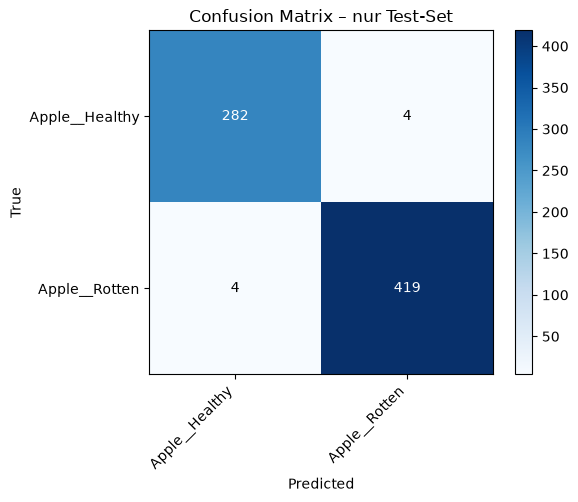

In [31]:
y_true, y_pred, y_conf = [], [], []

for images, labels in test_ds:
    preds = best_head_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_conf.extend(np.max(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_conf = np.array(y_conf)

print("=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im)
ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix – nur Test-Set")
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_testset.png", dpi=150)
plt.show()

## 11. Falsch klassifizierte Bilder anzeigen

Falsch klassifiziert: 74 Bilder


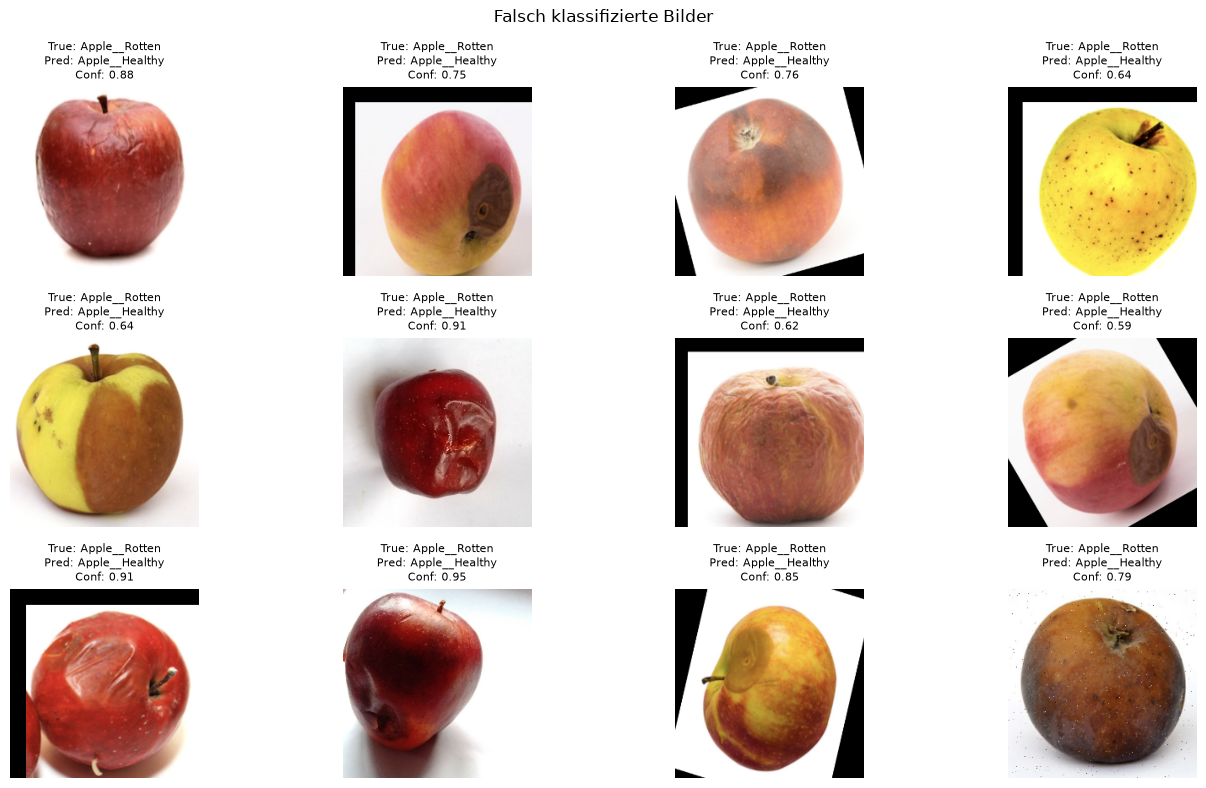

In [20]:
wrong_images, wrong_true, wrong_pred, wrong_conf = [], [], [], []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    confidences = np.max(preds, axis=1)

    for i in range(len(labels)):
        true_label = int(labels[i].numpy())
        pred_label = int(pred_labels[i])

        if true_label != pred_label:
            wrong_images.append(images[i].numpy().astype("uint8"))
            wrong_true.append(true_label)
            wrong_pred.append(pred_label)
            wrong_conf.append(float(confidences[i]))

print(f"Falsch klassifiziert: {len(wrong_images)} Bilder")

n = min(12, len(wrong_images))
if n > 0:
    plt.figure(figsize=(14, 8))
    for i in range(n):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(wrong_images[i])
        plt.title(
            f"True: {class_names[wrong_true[i]]}\n"
            f"Pred: {class_names[wrong_pred[i]]}\n"
            f"Conf: {wrong_conf[i]:.2f}",
            fontsize=8
        )
        plt.axis("off")
    plt.suptitle("Falsch klassifizierte Bilder", fontsize=12)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "wrong_predictions.png", dpi=150)
    plt.show()
else:
    print("Keine falsch klassifizierten Bilder gefunden.")

## 12. Trainingskurven einzelner Kandidaten anzeigen

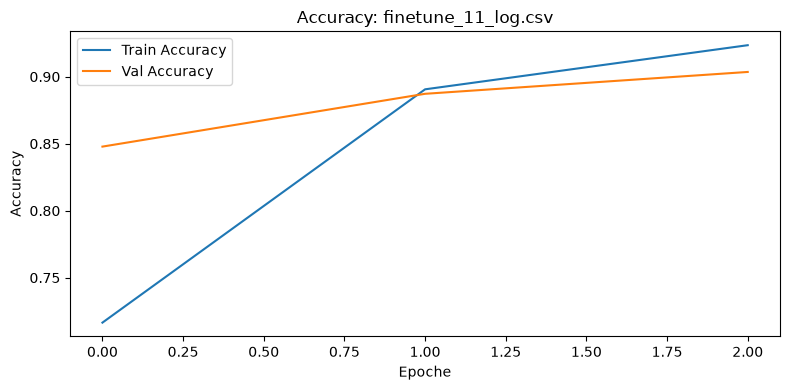

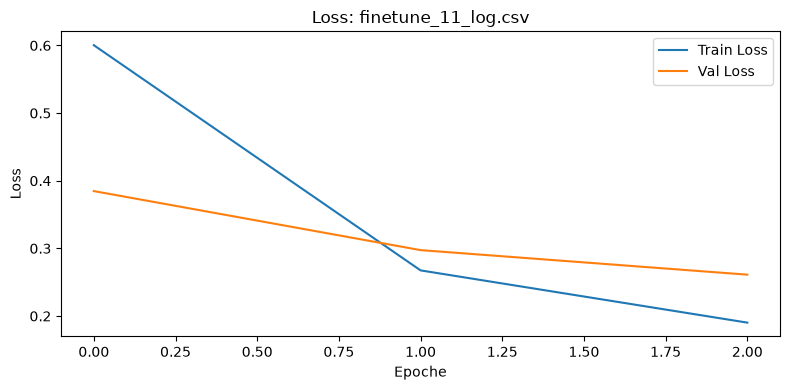

In [21]:
def plot_training_log(log_path):
    """Zeigt Accuracy und Loss eines gespeicherten CSVLogger-Logs."""
    log_path = Path(log_path)
    if not log_path.exists():
        raise FileNotFoundError(log_path)

    log_df = pd.read_csv(log_path)

    plt.figure(figsize=(8, 4))
    plt.plot(log_df["epoch"], log_df["accuracy"], label="Train Accuracy")
    plt.plot(log_df["epoch"], log_df["val_accuracy"], label="Val Accuracy")
    plt.xlabel("Epoche")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy: {log_path.name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(log_df["epoch"], log_df["loss"], label="Train Loss")
    plt.plot(log_df["epoch"], log_df["val_loss"], label="Val Loss")
    plt.xlabel("Epoche")
    plt.ylabel("Loss")
    plt.title(f"Loss: {log_path.name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Beispiel: Trainingskurve des besten Fine-Tuning-Modells
plot_training_log(best_finetune["log_path"])

## 13. Einzelbild-Inferenz

In [17]:
def predict_single_image(image_path: str, model, class_names: list):
    """Klassifiziert ein einzelnes Bild und gibt Klasse + Konfidenz zurück."""
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array, verbose=0)[0]
    predicted_index = int(np.argmax(predictions))
    predicted_class = class_names[predicted_index]
    confidence = float(np.max(predictions))

    print(f"Klasse:    {predicted_class}")
    print(f"Konfidenz: {confidence:.2%}")
    print("Alle Scores:")
    for cls, score in zip(class_names, predictions):
        print(f"  {cls}: {score:.2%}")

    return predicted_class, confidence

# Beispiel:
# predict_single_image(r"c:/Pfad/zum/apfelbild.jpg", model, class_names)

## 14. Grad-CAM für Testbilder

In [18]:
import matplotlib.cm as mpl_cm


def find_last_conv_layer_name(model):
    """Findet automatisch den letzten Conv2D-Layer im gesamten Modell."""
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.Model):
            for sub_layer in reversed(layer.layers):
                if isinstance(sub_layer, tf.keras.layers.Conv2D):
                    return sub_layer.name
        elif isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("Kein Conv2D-Layer gefunden.")


def make_gradcam_heatmap(img_array, model, last_conv_layer_name=None, pred_index=None):
    """Erstellt eine Grad-CAM Heatmap für ein einzelnes Bild-Batch-Array."""
    if last_conv_layer_name is None:
        last_conv_layer_name = find_last_conv_layer_name(model)

    base_model = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model) and "mobilenet" in layer.name.lower():
            base_model = layer
            break

    if base_model is None:
        raise ValueError("MobileNetV2-Base-Model wurde nicht gefunden.")

    last_conv_layer = base_model.get_layer(last_conv_layer_name)
    conv_model = tf.keras.Model(base_model.input, last_conv_layer.output)

    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input

    base_model_found = False
    for layer in model.layers:
        if layer is base_model:
            base_model_found = True
            continue
        if base_model_found:
            x = layer(x)

    classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        preprocessed = model.get_layer("mobilenet_preprocess")(img_array)
        conv_outputs = conv_model(preprocessed)
        predictions = classifier_model(conv_outputs)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), int(tf.argmax(predictions[0]).numpy()), float(tf.reduce_max(predictions[0]).numpy())


def create_gradcam_overlay(image, heatmap, alpha=0.4):
    """Erstellt ein Overlay ohne matplotlib.cm.get_cmap, um Versionsprobleme zu vermeiden."""
    heatmap_uint8 = np.uint8(255 * heatmap)
    colormap = mpl_cm.jet(np.arange(256))[:, :3]
    heatmap_rgb = colormap[heatmap_uint8]
    heatmap_rgb = tf.image.resize(heatmap_rgb, IMG_SIZE).numpy()

    image_norm = image.astype("float32") / 255.0
    overlay = heatmap_rgb * alpha + image_norm * (1 - alpha)
    overlay = np.clip(overlay, 0, 1)
    return overlay

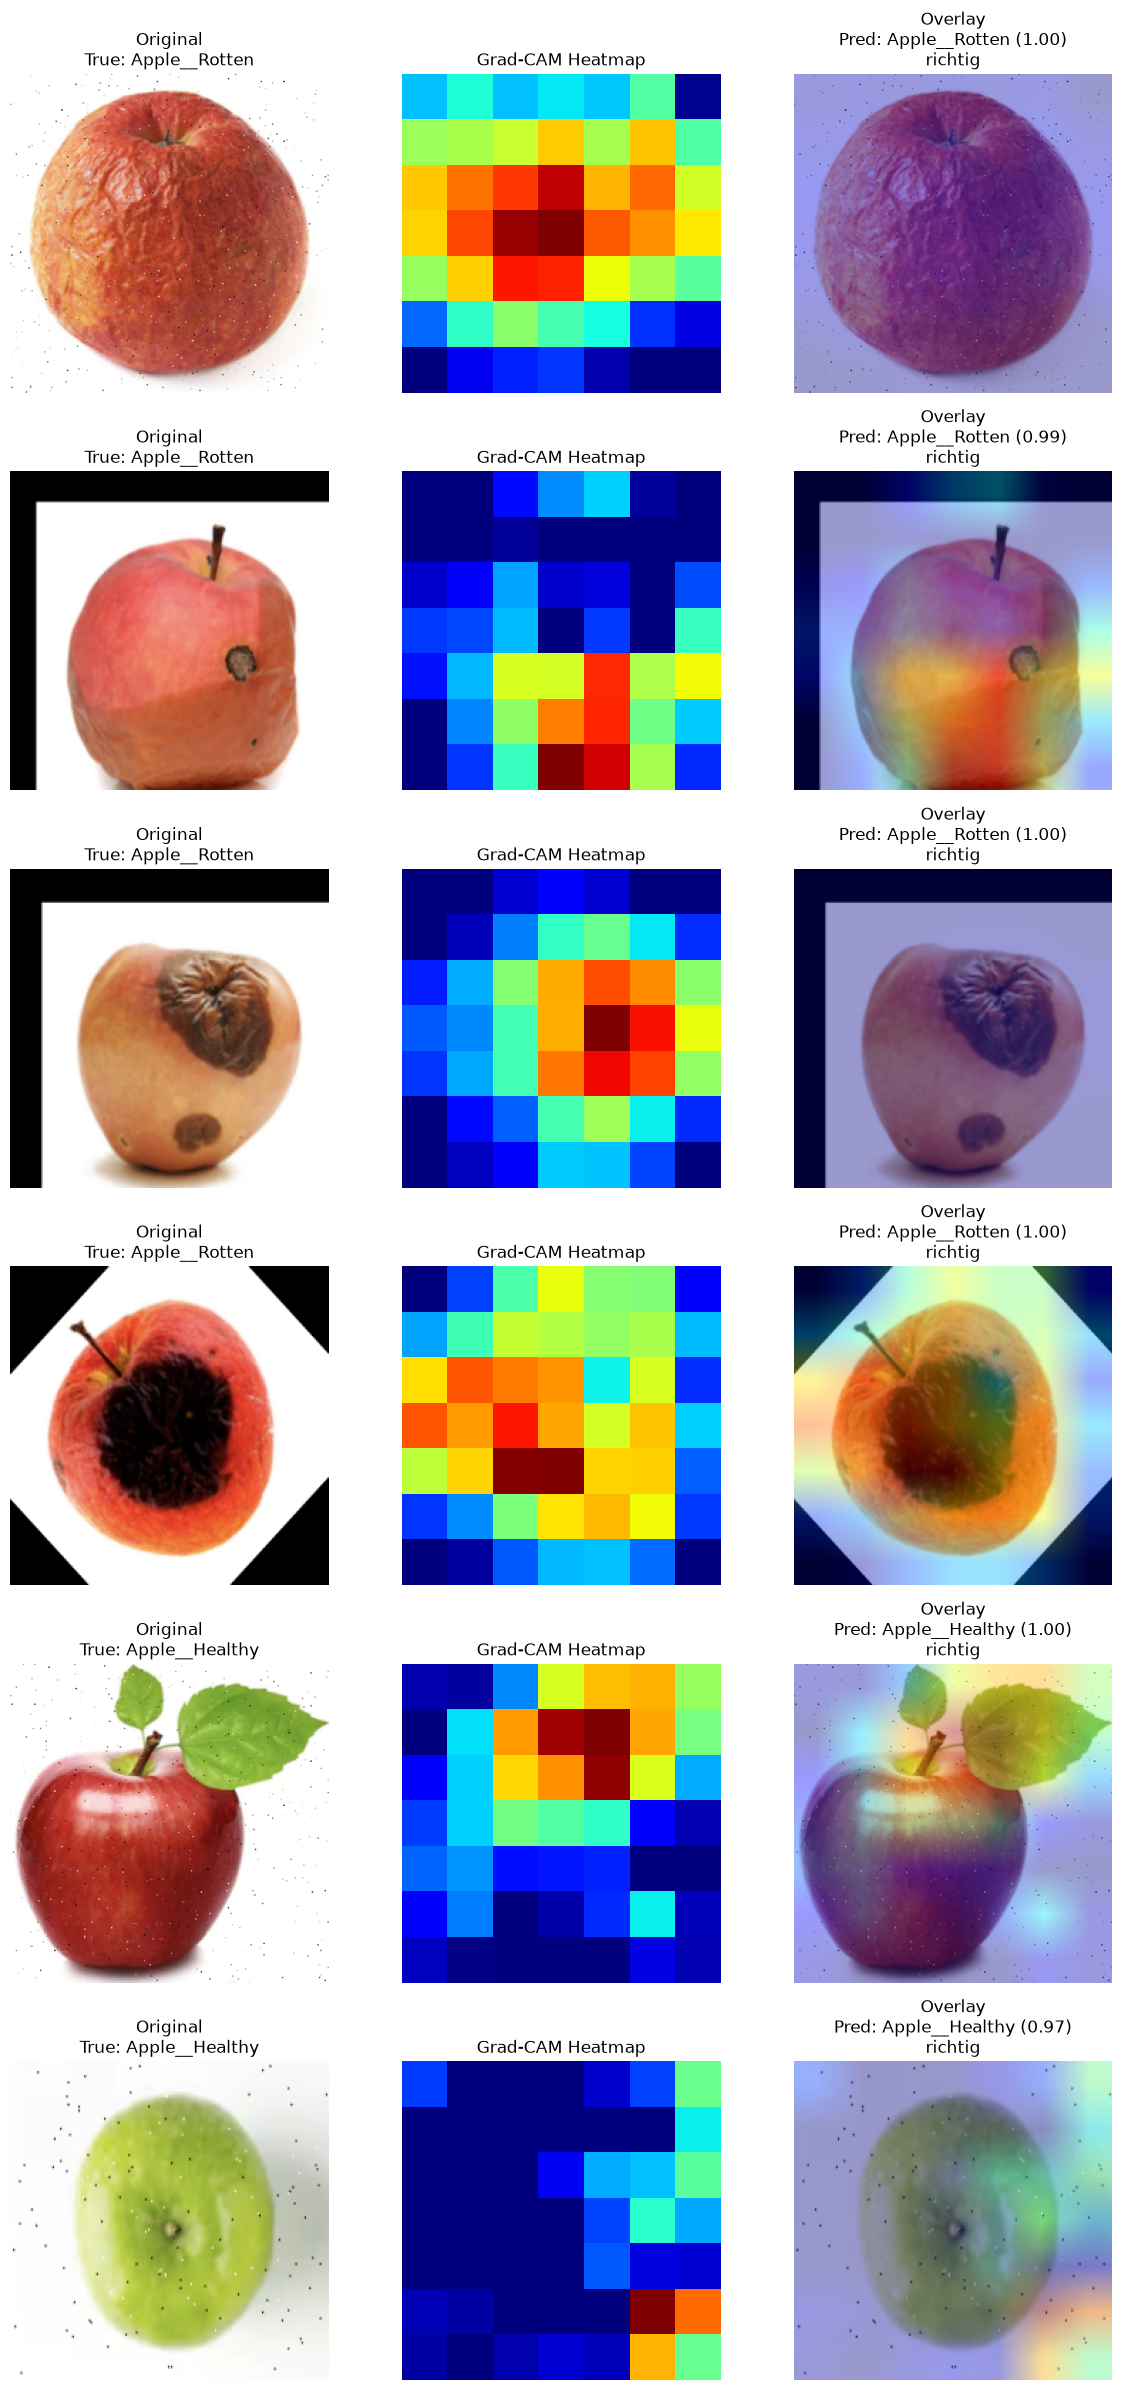

In [23]:
def display_gradcam_batch(test_ds, model, class_names, n=6):
    """Zeigt Originalbild, Heatmap und Overlay für n Bilder aus dem Testset."""
    images, labels = next(iter(test_ds))
    n = min(n, len(images))

    fig, axes = plt.subplots(n, 3, figsize=(12, n * 4))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        img = images[i].numpy().astype("uint8")
        img_batch = tf.expand_dims(images[i], axis=0)
        true_idx = int(labels[i].numpy())

        heatmap, pred_idx, confidence = make_gradcam_heatmap(img_batch, model)
        overlay = create_gradcam_overlay(img, heatmap, alpha=0.4)

        correct = "richtig" if pred_idx == true_idx else "falsch"

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Original\nTrue: {class_names[true_idx]}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(heatmap, cmap="jet")
        axes[i, 1].set_title("Grad-CAM Heatmap")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title(
            f"Overlay\nPred: {class_names[pred_idx]} ({confidence:.2f})\n{correct}"
        )
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "gradcam_examples.png", dpi=150)
    plt.show()

# Beispielaufruf:
display_gradcam_batch(test_ds, best_head_model, class_names, n=6)

## 15. Kurze Formulierung für Bericht oder Präsentation

In [25]:
berichtstext = f"""
Zur ressourcenschonenden Hyperparameteroptimierung wurde zunächst nur der Klassifikationskopf des vortrainierten MobileNetV2-Modells trainiert, während die Feature-Extraction-Schichten eingefroren blieben. Dabei wurden verschiedene Kombinationen aus Dense-Neuronen, Dropout-Rate und Lernrate über wenige Epochen anhand des Validierungsdatensatzes verglichen. Nur die besten {TOP_K} Kandidaten wurden anschließend mittels Fine-Tuning weiter optimiert und abschließend auf dem unabhängigen Testdatensatz evaluiert.
"""

print(berichtstext)


Zur ressourcenschonenden Hyperparameteroptimierung wurde zunächst nur der Klassifikationskopf des vortrainierten MobileNetV2-Modells trainiert, während die Feature-Extraction-Schichten eingefroren blieben. Dabei wurden verschiedene Kombinationen aus Dense-Neuronen, Dropout-Rate und Lernrate über wenige Epochen anhand des Validierungsdatensatzes verglichen. Nur die besten 3 Kandidaten wurden anschließend mittels Fine-Tuning weiter optimiert und abschließend auf dem unabhängigen Testdatensatz evaluiert.

